In [2]:

import re
import numpy as np
import matplotlib.pyplot as plt

# adjust matplotlib defaults to personal preferences
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

Exercise 1: Make encoder and decoder functions

In [6]:
# list of sentences
text = [ 'All that we are is the result of what we have thought',
         'To be or not to be that is the question',
         'Be yourself everyone else is already taken' ]

# create a vocab of unique words
allwords = re.split(r'\s',' '.join(text).lower())
vocab = sorted(set(allwords))

In [7]:
# create an encoder and decoder dictionaries
word2idex = { word: i for i, word in enumerate(vocab) }
idex2word = { i: word for i, word in enumerate(vocab) } 
word2idex, idex2word

({'all': 0,
  'already': 1,
  'are': 2,
  'be': 3,
  'else': 4,
  'everyone': 5,
  'have': 6,
  'is': 7,
  'not': 8,
  'of': 9,
  'or': 10,
  'question': 11,
  'result': 12,
  'taken': 13,
  'that': 14,
  'the': 15,
  'thought': 16,
  'to': 17,
  'we': 18,
  'what': 19,
  'yourself': 20},
 {0: 'all',
  1: 'already',
  2: 'are',
  3: 'be',
  4: 'else',
  5: 'everyone',
  6: 'have',
  7: 'is',
  8: 'not',
  9: 'of',
  10: 'or',
  11: 'question',
  12: 'result',
  13: 'taken',
  14: 'that',
  15: 'the',
  16: 'thought',
  17: 'to',
  18: 'we',
  19: 'what',
  20: 'yourself'})

Exercise 2: Wrap the encoder/decoder into functions

In [10]:
### the encoder function
def encoder(text):
    # parse the text into words
    words = re.split(r'\s', text.lower())

    # return the vector of word indices
    return [ word2idex[word] for word in words ]

### now for the decoder function
def decoder(indices):

    # find the words corresponding to the indices, and join into one string
    return ' '.join([ idex2word[i] for i in indices ])

In [9]:
# reminder of the available words
print(vocab)

['all', 'already', 'are', 'be', 'else', 'everyone', 'have', 'is', 'not', 'of', 'or', 'question', 'result', 'taken', 'that', 'the', 'thought', 'to', 'we', 'what', 'yourself']


In [11]:
# create a new sentence using the vocab
newtext = 'we already are the result of what ' \
            'everyone else already thought'

newtext_indices = encoder(newtext)
decoded_newtext = decoder(newtext_indices)

print(f'Original text: {newtext}')
print(f'Encoded text: {newtext_indices}')
print(f'Decoded text: {decoded_newtext}')

Original text: we already are the result of what everyone else already thought
Encoded text: [18, 1, 2, 15, 12, 9, 19, 5, 4, 1, 16]
Decoded text: we already are the result of what everyone else already thought


Exercise 3: Visualize the tokens

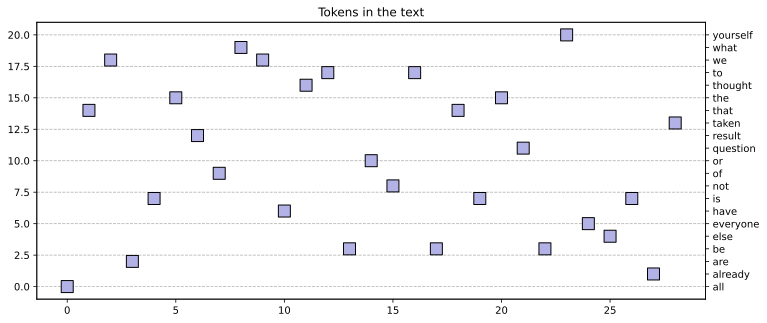

In [13]:
# get all the texts and all the tokens
all_text = ' '.join(text).lower()
tokens = encoder(all_text)

# create a figure
_,ax = plt.subplots(1,figsize=(12,5))

# plot the tokens
ax.plot(tokens, 'ks', markersize=12, markerfacecolor=[.7,.7,.9])
ax.set_title('Tokens in the text')
ax.grid(linestyle='--', axis='y')

# invisible axis for right-hand-side labels
ax2 = ax.twinx()
ax2.plot(tokens, alpha=0)
ax2.set(yticks=range(len(vocab)), yticklabels=vocab)

plt.show()

Exercise 4: Explore context surrounding target tokens

In [16]:
# what words are in the cotext of "to"
targetword = 'to'
targetindex = word2idex[targetword]

# find indices
targetindices = np.where(np.array(tokens) == targetindex)[0]
print(f'Indices of the word "{targetword}": {targetindices}\n\n')

# print context
for t in targetindices:
    print(f'Context of "{targetword}" in sentence {t//len(text[0].split())} is: "{text[t//len(text[0].split())]}"')
    print([vocab[i] for i in tokens[t-1:t+2]])  #token strings

Indices of the word "to": [12 16]


Context of "to" in sentence 1 is: "To be or not to be that is the question"
['thought', 'to', 'be']
Context of "to" in sentence 1 is: "To be or not to be that is the question"
['not', 'to', 'be']


Exercise 5: One-hot encoding

In [22]:
word_matrix = np.zeros((len(allwords), len(vocab)), dtype=int)

for i, word in enumerate(allwords):
    word_matrix[i, word2idex[word]] = 1

print(f'One-hot encoding matrix is of size {word_matrix.shape}\n')
print(word_matrix)

# create the matrix
for i,word in enumerate(allwords):
    word_matrix[i, word2idex[word]] = 1

# show the results
print(f'One-hot encoding matrix is of size {word_matrix.shape}\n')
print(word_matrix)
     

One-hot encoding matrix is of size (29, 21)

[[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 

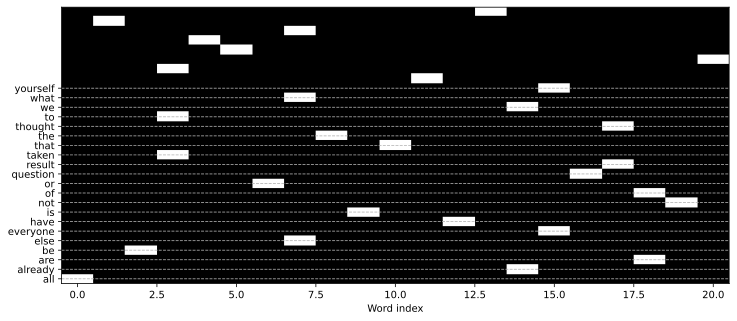

In [24]:
# the image of the one-hot encoding matrix is the same as in Exercise 2
_,ax = plt.subplots(1,figsize=(12,5))

plt.imshow(word_matrix, cmap='gray',origin='lower',aspect='auto')
ax.set(xlabel='Word index', yticks=range(len(vocab)), yticklabels=vocab)
ax.grid(linestyle='--', axis='y')
plt.show()
